In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\Tushar\\Documents\\Car Prediction\\cars_dataset.csv")
df.head()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Year               6019 non-null   int64  
 2   Kilometers_Driven  6019 non-null   int64  
 3   Fuel_Type          6019 non-null   object 
 4   Transmission       6019 non-null   object 
 5   Owner_Type         6019 non-null   object 
 6   Mileage            6017 non-null   object 
 7   Engine             5983 non-null   object 
 8   Power              5983 non-null   object 
 9   Seats              5977 non-null   float64
 10  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 517.4+ KB


In [4]:
df.isnull().sum()

Name                  0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64

In [5]:
df = df.dropna(subset=['Engine','Seats','Mileage',"Power"])

In [6]:
df["Mileage"] = df["Mileage"].str.extract(r'(\d+\.?\d*)').astype(float)
df["Engine"]  = df["Engine"].str.extract(r'(\d+\.?\d*)').astype(float)
df["Power"]   = df["Power"].str.extract(r'(\d+\.?\d*)').astype(float)
df["Seats"]   = df["Seats"].astype(float)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5975 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Year               5975 non-null   int64  
 2   Kilometers_Driven  5975 non-null   int64  
 3   Fuel_Type          5975 non-null   object 
 4   Transmission       5975 non-null   object 
 5   Owner_Type         5975 non-null   object 
 6   Mileage            5975 non-null   float64
 7   Engine             5975 non-null   float64
 8   Power              5872 non-null   float64
 9   Seats              5975 non-null   float64
 10  Price              5975 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 560.2+ KB


In [8]:
df.isnull().sum()

Name                   0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                0
Engine                 0
Power                103
Seats                  0
Price                  0
dtype: int64

In [9]:
df.nunique()

Name                 1855
Year                   22
Kilometers_Driven    3080
Fuel_Type               4
Transmission            2
Owner_Type              4
Mileage               430
Engine                145
Power                 368
Seats                   9
Price                1369
dtype: int64

In [10]:
"""df["Name"] = df["Name"].str.replace(" ", "")
df["Mileage"] = df["Mileage"].str.extract(r'(\d+\.?\d*)')
df["Engine"] = df["Engine"].str.extract(r'(\d+\.?\d*)')
df["Power"] = df["Power"].str.extract(r'(\d+\.?\d*)')"""

'df["Name"] = df["Name"].str.replace(" ", "")\ndf["Mileage"] = df["Mileage"].str.extract(r\'(\\d+\\.?\\d*)\')\ndf["Engine"] = df["Engine"].str.extract(r\'(\\d+\\.?\\d*)\')\ndf["Power"] = df["Power"].str.extract(r\'(\\d+\\.?\\d*)\')'

In [11]:
df = df[df["Name"].map(df["Name"].value_counts()) > 5]
df

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
3,Maruti Ertiga VDI,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
6,Nissan Micra Diesel XV,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50
...,...,...,...,...,...,...,...,...,...,...,...
6012,Toyota Innova 2.5 V Diesel 7-seater,2011,45004,Diesel,Manual,First,12.80,2494.0,102.00,7.0,9.48
6013,Honda Amaze VX i-DTEC,2015,70602,Diesel,Manual,First,25.80,1498.0,98.60,5.0,4.83
6014,Maruti Swift VDI,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00


In [12]:
df["Name"] = df["Name"].str.replace(" ", "", regex=False)
df

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,MarutiWagonRLXICNG,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,HyundaiCreta1.6CRDiSXOption,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
3,MarutiErtigaVDI,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,AudiA4New2.0TDIMultitronic,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
6,NissanMicraDieselXV,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50
...,...,...,...,...,...,...,...,...,...,...,...
6012,ToyotaInnova2.5VDiesel7-seater,2011,45004,Diesel,Manual,First,12.80,2494.0,102.00,7.0,9.48
6013,HondaAmazeVXi-DTEC,2015,70602,Diesel,Manual,First,25.80,1498.0,98.60,5.0,4.83
6014,MarutiSwiftVDI,2014,27365,Diesel,Manual,First,28.40,1248.0,74.00,5.0,4.75
6015,HyundaiXcent1.1CRDiS,2015,100000,Diesel,Manual,First,24.40,1120.0,71.00,5.0,4.00


In [13]:
from sklearn.preprocessing import LabelEncoder

name_encoder = LabelEncoder()
fuel_encoder = LabelEncoder()
transmission_encoder = LabelEncoder()
owner_encoder = LabelEncoder()

df["Name"] = name_encoder.fit_transform(df["Name"])
df["Fuel_Type"] = fuel_encoder.fit_transform(df["Fuel_Type"])
df["Transmission"] = transmission_encoder.fit_transform(df["Transmission"])
df["Owner_Type"] = owner_encoder.fit_transform(df["Owner_Type"])
df.head()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,189,2010,72000,0,1,0,26.60,998.0,58.16,5.0,1.75
1,66,2015,41000,1,1,0,19.67,1582.0,126.20,5.0,12.50
3,158,2012,87000,1,1,0,20.77,1248.0,88.76,7.0,6.00
4,4,2013,40670,1,0,2,15.20,1968.0,140.80,5.0,17.74
6,207,2013,86999,1,1,0,23.08,1461.0,63.10,5.0,3.50


In [14]:
df["Mileage"].value_counts()

Mileage
18.90    138
18.60     93
20.36     80
17.00     77
21.10     65
        ... 
20.85      2
16.51      1
13.60      1
19.64      1
14.81      1
Name: count, Length: 160, dtype: int64

In [15]:
df["Name"].value_counts()

Name
135    49
175    45
168    34
44     34
176    31
       ..
228     6
179     6
157     6
101     6
122     6
Name: count, Length: 263, dtype: int64

In [16]:
X = df.drop(['Price'], axis=1)
X.dropna()
X = X.dropna()
X.isnull().sum()

Name                 0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

In [17]:
Y = df.loc[X.index, "Price"]

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.25, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[ 1.5660856 ,  1.65266982, -0.65156116, ..., -0.07287796,
        -0.38547892, -0.38699743],
       [-0.29020859,  0.14009776,  0.06275965, ..., -0.6154168 ,
        -0.59502422, -0.38699743],
       [-0.99800422,  0.51824077, -0.53156218, ..., -0.07468041,
         0.28921089, -0.38699743],
       ...,
       [ 0.07036654,  0.14009776, -0.0723135 , ...,  1.15459363,
         0.81192278,  2.2561769 ],
       [-0.25014469,  1.27452681, -1.34200104, ..., -0.6154168 ,
        -0.52755524, -0.38699743],
       [-0.82439397,  1.27452681, -1.02801001, ...,  0.09475032,
         0.38131871, -0.38699743]])

In [20]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)

RandomForestRegressor()

In [21]:
X_test = scaler.transform(X_test)

In [22]:
Y_predict = model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_predict)

0.9398889412007444

In [24]:
# Hyundai Xcent 1.1 CRDi S	2015	100000	Diesel	Manual	First	24.40	1120.0	71.00	5.0	4.00
# Maruti Wagon R LXI CNG	2010	72000	CNG	Manual	First	26.60	998.0	58.16	5.0	1.75
# Hyundai Creta 1.6 CRDi SX Option	2015	41000	Diesel	Manual	First	19.67	1582.0	126.20	5.0	12.50

"""new_data = pd.DataFrame([{
    "Name": "Hyundai Creta 1.6 CRDi SX Option",
    "Year": 2015,
    "Kilometers_Driven": 41000,
    "Fuel_Type": "Diesel",
    "Transmission": "Manual",
    "Owner_Type": "First",
    "Mileage": 19.67,
    "Engine": 1582.0,
    "Power": 126.20,
    "Seats": 5.0
}])

new_data["Name"] = new_data["Name"].str.replace(" ", "")

# Apply encoders
new_data["Name"] = name_encoder.transform(new_data["Name"])
new_data["Fuel_Type"] = fuel_encoder.transform(new_data["Fuel_Type"])
new_data["Transmission"] = transmission_encoder.transform(new_data["Transmission"])
new_data["Owner_Type"] = owner_encoder.transform(new_data["Owner_Type"])

"""

'new_data = pd.DataFrame([{\n    "Name": "Hyundai Creta 1.6 CRDi SX Option",\n    "Year": 2015,\n    "Kilometers_Driven": 41000,\n    "Fuel_Type": "Diesel",\n    "Transmission": "Manual",\n    "Owner_Type": "First",\n    "Mileage": 19.67,\n    "Engine": 1582.0,\n    "Power": 126.20,\n    "Seats": 5.0\n}])\n\nnew_data["Name"] = new_data["Name"].str.replace(" ", "")\n\n# Apply encoders\nnew_data["Name"] = name_encoder.transform(new_data["Name"])\nnew_data["Fuel_Type"] = fuel_encoder.transform(new_data["Fuel_Type"])\nnew_data["Transmission"] = transmission_encoder.transform(new_data["Transmission"])\nnew_data["Owner_Type"] = owner_encoder.transform(new_data["Owner_Type"])\n\n'

In [25]:
"""new_data = scaler.transform(new_data)

# Prediction
prediction = model.predict(new_data)

print("Predicted Price:", prediction[0])"""

NameError: name 'new_data' is not defined

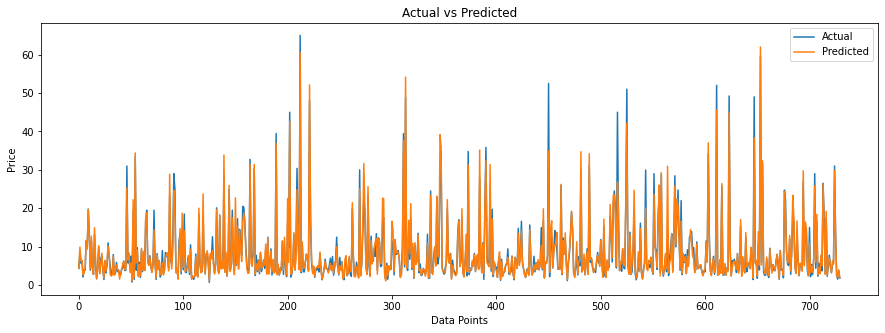

In [26]:
plt.figure(figsize=(15,5))
plt.plot(Y_test.values, label="Actual")
plt.plot(Y_predict, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Data Points")
plt.ylabel("Price")

plt.show()


In [27]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
pickle

<module 'pickle' from 'C:\\python310\\lib\\pickle.py'>

In [28]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
pickle

<module 'pickle' from 'C:\\python310\\lib\\pickle.py'>

In [31]:
import pickle
with open("name_encoder.pkl", "wb") as f:
    pickle.dump(name_encoder, f)

with open("fuel_encoder.pkl", "wb") as f:
    pickle.dump(fuel_encoder, f)
    
with open("transmission_encoder.pkl", "wb") as f:
    pickle.dump(transmission_encoder, f)
    
with open("owner_encoder.pkl", "wb") as f:
    pickle.dump(owner_encoder, f)
    
"""name_encoder = LabelEncoder()
fuel_encoder = LabelEncoder()
transmission_encoder = LabelEncoder()
owner_encoder = LabelEncoder()
"""

'name_encoder = LabelEncoder()\nfuel_encoder = LabelEncoder()\ntransmission_encoder = LabelEncoder()\nowner_encoder = LabelEncoder()\n'